In [1]:
from value import Value
from slp import Neuron, Layer
import pandas as pd

In [2]:
data = pd.read_csv("data.csv")
print(data['label'].unique())

# Setosa = 0, Versicolor = 1  -> same mapping as the sheet (G2 and G3)
data['label'] = data['label'].map({'Iris-setosa': 0, 'Iris-versicolor': 1})
data.head()

<StringArray>
['Iris-setosa', 'Iris-versicolor']
Length: 2, dtype: str


,x1,x2,x3,x4,label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
data_train = pd.concat([data.iloc[0:40],  data.iloc[50:90]]).reset_index(drop=True)
data_val   = pd.concat([data.iloc[40:50], data.iloc[90:100]]).reset_index(drop=True)

for name, d in [("train", data_train), ("val", data_val)]:
    print(f"{name:5s} {len(d):3d} rows  |  setosa {(d['label'] == 0).sum():2d}"
          f"  versicolor {(d['label'] == 1).sum():2d}")

train  80 rows  |  setosa 40  versicolor 40
val    20 rows  |  setosa 10  versicolor 10


In [4]:
cols = ['x1', 'x2', 'x3', 'x4']

x_train = data_train[cols].values.tolist()
y_train = data_train['label'].tolist()

x_val = data_val[cols].values.tolist()
y_val = data_val['label'].tolist()

In [ ]:
model = Layer(4, 1)
print(model)
print("initial parameters:", [p.data for p in model.parameters()])

lr = 0.1       
epochs = 5    

Layer of [Sigmoid Neuron(4)]
initial parameters: [0.5, 0.5, 0.5, 0.5, 0.5]


In [6]:
def sse_loss(pred, target):
    """Squared error for ONE sample: (g(z) - t)^2  --  sheet column R."""
    return (pred - target) ** 2

In [ ]:
def copy_weights(src, dst):
    """Copy every parameter value from src into dst (same shapes)."""
    for p_src, p_dst in zip(src.parameters(), dst.parameters()):
        p_dst.data = p_src.data


history = []

for epoch in range(1, epochs + 1):
    # ---------------- training ----------------
    total_sse, correct = 0.0, 0

    for xi, yi in zip(x_train, y_train):
        model.zero_grad()             # clear gradients from the previous sample
        pred = model(xi)              # forward: z then g(z)
        loss = sse_loss(pred, yi)     # per-sample error
        loss.backward()               # gradients (sheet columns T:X)

        for p in model.parameters():  # sheet column I:  theta <- theta - lr * grad
            p.data -= lr * p.grad

        total_sse += loss.data
        correct += int((pred.data > 0.5) == (yi == 1))

    train_sse = total_sse / len(x_train)
    train_acc = correct / len(x_train)

    val_model = Layer(4, 1)
    copy_weights(model, val_model)

    val_sse, val_correct = 0.0, 0
    for xi, yi in zip(x_val, y_val):
        val_model.zero_grad()
        pred = val_model(xi)
        loss = sse_loss(pred, yi)
        loss.backward()
        for p in val_model.parameters():
            p.data -= lr * p.grad
        val_sse += loss.data
        val_correct += int((pred.data > 0.5) == (yi == 1))

    # accuracy of the same weights with NO further updates (plain evaluation)
    eval_model = Layer(4, 1)
    copy_weights(model, eval_model)
    eval_correct = sum(int((eval_model(xi).data > 0.5) == (yi == 1))
                       for xi, yi in zip(x_val, y_val))

    history.append({
        "epoch": epoch,
        "train_sse": train_sse,
        "train_acc": train_acc,
        "val_sse": val_sse / len(x_val),
        "val_acc": val_correct / len(x_val),
        "val_acc_frozen": eval_correct / len(x_val),
    })

    print(f"epoch {epoch}   train SSE {train_sse:.6f}  train acc {train_acc:.2%}"
          f"   | val SSE {val_sse/len(x_val):.6f}  val acc {val_correct/len(x_val):.2%}"
          f"  (frozen {eval_correct/len(x_val):.2%})")

epoch 1   train SSE 0.449889  train acc 52.50%   | val SSE 0.100124  val acc 85.00%  (frozen 50.00%)
epoch 2   train SSE 0.037452  train acc 95.00%   | val SSE 0.065138  val acc 90.00%  (frozen 50.00%)
epoch 3   train SSE 0.024372  train acc 97.50%   | val SSE 0.045832  val acc 95.00%  (frozen 50.00%)
epoch 4   train SSE 0.017357  train acc 97.50%   | val SSE 0.034639  val acc 100.00%  (frozen 85.00%)
epoch 5   train SSE 0.012740  train acc 98.75%   | val SSE 0.027801  val acc 100.00%  (frozen 100.00%)


In [8]:
summary = pd.DataFrame(history)
summary

,epoch,train_sse,train_acc,val_sse,val_acc,val_acc_frozen
0,1,0.449889,0.5250,0.100124,0.85,0.50
1,2,0.037452,0.9500,0.065138,0.90,0.50
2,3,0.024372,0.9750,0.045832,0.95,0.50
3,4,0.017357,0.9750,0.034639,1.00,0.85
4,5,0.012740,0.9875,0.027801,1.00,1.00


In [ ]:
print("final parameters:")
names = ["teta1", "teta2", "teta3", "teta4", "bias"]
for name, p in zip(names, model.parameters()):
    print(f"  {name:<6} {p.data: .6f}")

print(f"\nsample {x_train[0]} -> pred {model(x_train[0]).data:.4f} | true {y_train[0]}")


final parameters:
  teta1  -0.241802
  teta2  -0.416903
  teta3   1.122214
  teta4   0.824059
  bias    0.257720

sample [5.1, 3.5, 1.4, 0.2] -> pred 0.3321 | true 0


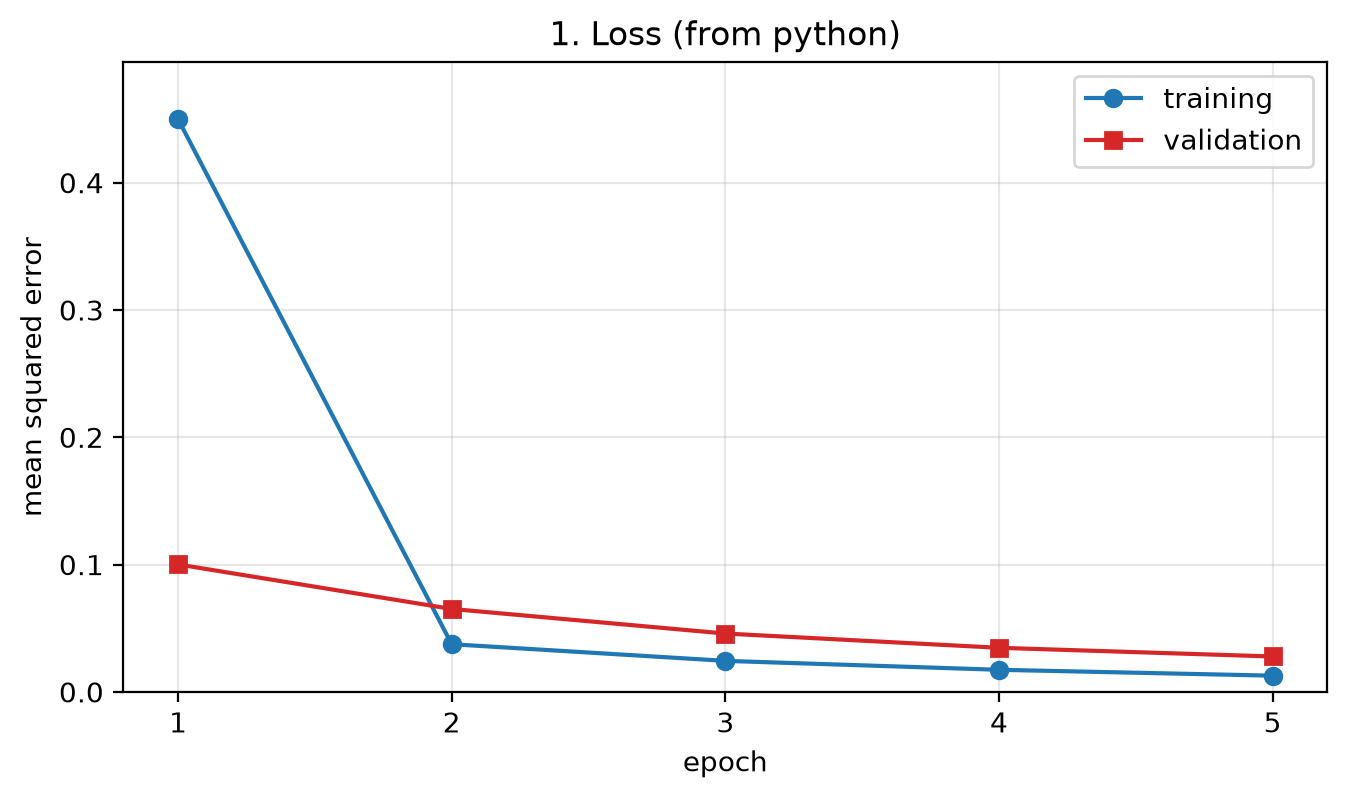

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=200)
ax.plot(summary['epoch'], summary['train_sse'], marker='o', color='#1f77b4', label='training')
ax.plot(summary['epoch'], summary['val_sse'],   marker='s', color='#d62728', label='validation')
ax.set_title('1. Loss (from python)')
ax.set_ylabel('mean squared error')
ax.set_ylim(0, float(max(summary['train_sse'].max(), summary['val_sse'].max())) * 1.1)
ax.legend(loc='upper right')
ax.set_xlabel('epoch')
ax.set_xticks(summary['epoch'])
ax.grid(alpha=.3)
fig.subplots_adjust(left=0.11, right=0.97, top=0.88, bottom=0.13)
fig.savefig('figures/loss_python.png', dpi=200)
plt.show()


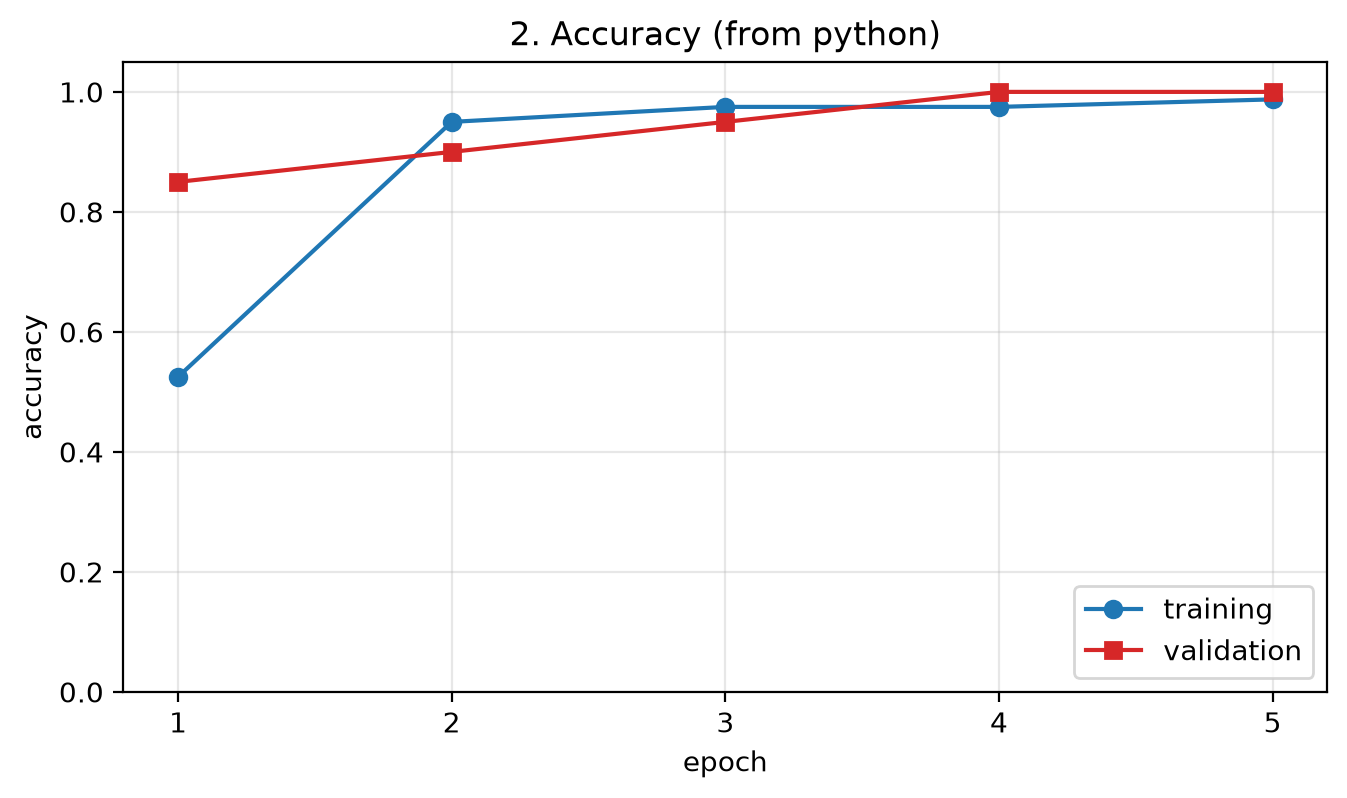

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=200)
ax.plot(summary['epoch'], summary['train_acc'], marker='o', color='#1f77b4', label='training')
ax.plot(summary['epoch'], summary['val_acc'],   marker='s', color='#d62728', label='validation')
ax.set_title('2. Accuracy (from python)')
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.set_xlabel('epoch')
ax.set_xticks(summary['epoch'])
ax.grid(alpha=.3)
fig.subplots_adjust(left=0.11, right=0.97, top=0.88, bottom=0.13)
fig.savefig('figures/accuracy_python.png', dpi=200)
plt.show()
